# Model ENSO full 12-2022

December 2022, January 2023, July 2024

**After model training on `Model_ENSOclim_Akaike` and `Model_Akaike`, we use this file to input gSST and climate and output our estimates of area burned. At the very end of this file, we generate estimated annual area burned after adding the average of a 500-member ensemble of burned-area estimates in which our estimates of log10(BA) are permuted by adding randomly drawn empirical values of Error.**


Caroline Juang, c.juang@columbia.edu

**Inputs:**
* SST gradient (1982-present) - build it following the README
* trained models `Model_ENSOclim_Akaike` (SST gradient -> climate)
* trained models `Model_Akaike` (climate -> burned area)

**Variables**
* `sstpred` generally refers to the detrended SST gradient, which is the detrended-SST gradient scenario put into the climate->burned area model.
* `climpred` generally refers to the observed SST gradient, put into the climate->burned area model.

**Outputs:**
* Predicted climate (1983-present) (but only for the relevant variables to the climate->burned area model)
* Predicted burned area (1984-present) from the trended and detrended scenarios into the climate->burned area model.
* Predicted burned area, detrended. `wumiDT`.

This model will predict burned area in ecoregions in the western US using seasonal SST gradient values.

The model is based on the outputs of `Model_ENSOclim_Akaike` and `Model_Akaike`.

Data source:
* NOAA sea surface temperature, https://psl.noaa.gov/data/gridded/data.noaa.ersst.v5.html

save and load models

Machine Learning Mastery: https://machinelearningmastery.com/save-load-machine-learning-models-python-scikit-learn/

In [1]:
# import

from customconfig import *
from customscripts import *

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import joblib

In [2]:
# customize seasons for climate variables

# customize number of rolling periods
time_length = int(finalyear-firstyear+1) # get length of timeseries
# translate years into dates
firsttime = str(firstyear)+'-01-01'
finaltime = str(finalyear)+'-12-31'

# Read the climate index from the .txt file
with open('0_climindname.txt', 'r') as f:
    climindname = f.read().strip()
print(climindname +' will be used for the SST gradient')
climindnameDT = 'DeTrend_'+climindname
climfilename = 'DeTrendClimObs_'+climindname # sst-predicted BA

# importing data string
data_string = 'data//'
model_string = 'model//'+climindname+'//'
predict_string = 'predicted//'+climindname+'//'

# folder for saving figures
figfolder = 'your_fig_folder' # customize this

patch125-155_nino3-34 will be used for the SST gradient


## Import burned area data
from `Data_CreateModelData`

In [3]:
# import observed burned area
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')
print('imported '+filename+' all, for, non')

imported data//WUMI-ecoprovinces all, for, non


## Import observed SST gradient data
from `Data_CreateENSOIndex` and `Data_CreateModelData`

In [4]:
# import observed SST gradient
filename = data_string + 'sstgrad_seasons_' + climindname+'_82_y.txt'
climind82_seasons = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# import de-trended SST gradient
filename = data_string + 'sstgrad_seasons_' + climindnameDT+'_82_y.txt'
climind82_seasonsDT = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# import observed SST gradient (with extra year, for comparison)
filename = data_string + 'sstgrad_seasons_' + climindname+'_81_y.txt'
climind81_seasons = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# IMPORT gSST AVERAGE (average of concurrent-season and prior-season)
# import observed SST gradient
filename = data_string + 'sstgrad_seasons_' + climindname+'_82_y_avgcurr-prior.txt'
climind82_seasonsavg = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# import de-trended SST gradient
filename = data_string + 'sstgrad_seasons_' + climindnameDT+'_82_y_avgcurr-prior.txt'
climind82_seasonsDTavg = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# put the dataframes together
climind82_seasons = pd.concat([climind82_seasons, climind82_seasonsavg], axis=1)
climind82_seasonsDT = pd.concat([climind82_seasonsDT, climind82_seasonsDTavg], axis=1)

imported data//sstgrad_seasons_patch125-155_nino3-34_82_y.txt
imported data//sstgrad_seasons_DeTrend_patch125-155_nino3-34_82_y.txt
imported data//sstgrad_seasons_patch125-155_nino3-34_81_y.txt
imported data//sstgrad_seasons_patch125-155_nino3-34_82_y_avgcurr-prior.txt
imported data//sstgrad_seasons_DeTrend_patch125-155_nino3-34_82_y_avgcurr-prior.txt


## Import observed climate data
from `Data_CreateModelData`

In [5]:
# import OBSERVED climate data to feed into models
# climate is predicted using SST, but this is the climate observed data to check

dfframesall = {}
dfframesfor = {}
dfframesnon = {}

climind = pd.read_csv(data_string + 'gradient_'+climindname+'.txt', header=None, sep=",", skiprows=[0]).set_index(0)
for iecoreg in np.arange(len(province_num)):
    filename = data_string + 'climate_ecoprovinces_'
    print(dfnames[iecoreg])
    dfframesall[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_all.txt').set_index('Unnamed: 0')
    dfframesfor[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_for.txt').set_index('Unnamed: 0')
    dfframesnon[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_non.txt').set_index('Unnamed: 0')

allwestUS
ecoprov1
ecoprov2
ecoprov3
ecoprov4
ecoprov5
ecoprov6
ecoprov7
ecoprov8
ecoprov9
ecoprov10
ecoprov12
ecoprov13
ecoprov14
ecoprov15
ecoprov16
ecoprov17
ecoprov18
ecoprov19
ecoprov20
ecoprov21


## Import model outputs
from `Model_ENSOclim_Akaike` and `Model_Akaike`

In [6]:
# get the model input variable names from the txt files
# sst gradient to predict climate variables

with open(model_string + "modeloutput_sst_all_all.txt", "r") as f:
    inputsall = [line.strip() for line in f]
f.close()
with open(model_string + "modeloutput_sst_for.txt", "r") as f:
    inputsfor = [line.strip() for line in f]
f.close()
with open(model_string + "modeloutput_sst_non.txt", "r") as f:
    inputsnon = [line.strip() for line in f]
f.close()

# get indices of where each ecoregion's outputs begin
iinputsall = [i for i, e in 
               enumerate(inputsall) if "+++" in e]
# get ecoregions so iteration is not manual
iinputsfor = [i for i, e in 
               enumerate(inputsfor) if "+++" in e]
# get ecoregions so iteration is not manual
iinputsnon = [i for i, e in 
               enumerate(inputsnon) if "+++" in e]
# add in last index
iinputsall.append(len(inputsall)+1)
iinputsfor.append(len(inputsfor)+1)
iinputsnon.append(len(inputsnon)+1)

In [7]:
# get the model input variable names from the txt files
# climate variables to predict burned area

with open(model_string + "modeloutput_burnarea_for.txt", "r") as f:
    inputsfor_clim = [line.strip() for line in f]
f.close()
with open(model_string + "modeloutput_burnarea_non.txt", "r") as f:
    inputsnon_clim = [line.strip() for line in f]
f.close()

# get indices of where each ecoregion's outputs begin
# get ecoregions so iteration is not manual
iinputsfor_clim = [i for i, e in 
               enumerate(inputsfor_clim) if "+++" in e]
# get ecoregions so iteration is not manual
iinputsnon_clim = [i for i, e in 
               enumerate(inputsnon_clim) if "+++" in e]
# add in last index
iinputsfor_clim.append(len(inputsfor_clim)+1)
iinputsnon_clim.append(len(inputsnon_clim)+1)

# Setup for exporting burned area predictions
Predicted climate
* SST_obs-predicted climate
* SST_neg-predicted climate
* difference between climate_sstobs and climate_sstneg, called climate_preddiff
* observed climate with climate_preddiff subtracted from it, called climate_sstdiff

Predicted burned area
* SST-predicted burned area (observed SST, goes through SST-clim and clim-BA models)
* climate-predicted burned area (observed climate, goes through clim-BA model)

In [8]:
# a bunch of dictionaries for storage
# predicted climate from observed SST
dfsstpredclimall_obsSST = {}
dfsstpredclimfor_obsSST = {}
dfsstpredclimnon_obsSST = {}

# predicted climate from negative-trended SST
dfsstpredclimall_negSST = {}
dfsstpredclimfor_negSST = {}
dfsstpredclimnon_negSST = {}

# difference in predicted climate scenarios, climate_preddiff
dfsstpredclimall_preddiff = {}
dfsstpredclimfor_preddiff = {}
dfsstpredclimnon_preddiff = {}

# observed climate minus climate_preddiff
dfsstpredclimall_sstdiff = {}
dfsstpredclimfor_sstdiff = {}
dfsstpredclimnon_sstdiff = {}

In [9]:
# a bunch of dictionaries for storage

# SST-predicted, from climate_sstdiff
dfsstpredBAall = []
dfsstpredBAfor = []
dfsstpredBAnon = []
# climate-predicted, from observed climate
dfclimpredBAall = []
dfclimpredBAfor = []
dfclimpredBAnon = []

# scripts

In [10]:
# get the SST inputs needed
def modelinputsst_string(inputlist, varname, istart, iend):
    """
    Requirements: 
    inputlist = list of the Model_ENSOclim_Akaike model results (locally defined)
    ithisecoreg = the ecoregion name (globally defined)
    ithisecoregend = the next ecoregion name 
        in the list (globally defined)
    varname = the climate variable name (locally defined)
    """
    # narrow inputs list to ecoregion
    modellist = inputlist[istart:iend+1]
    # get all PREDICTING (where inputs start)
    iinputs = [i for i, e in 
               enumerate(modellist) if "PREDICTING" in e]
    # extract model inputs
    istart = modellist.index('PREDICTING ' + varname)
    if len(iinputs)>((iinputs.index(istart))+1): # 
        iend = iinputs[(iinputs.index(istart))+1]
        modelinputs = modellist[istart+1:iend] # range in list
    else:
        modelinputs = modellist[istart+1:] # last predictor to end of list
    return modelinputs

In [11]:
# get the SST inputs needed
def sortInputStrings(inputlist, istart, iend):
    """
    Requirements: 
    inputlist = list of the Model_ENSOclim_Akaike model results (locally defined)
    istart = the ecoregion name
    iend = the next ecoregion name in the list
    """
    # narrow inputs list to ecoregion
    modellistsort = inputlist[istart+1:iend+1]
    # separate concurrent and previous-year variables
    modely0names = [s for s in modellistsort if "y0" in s]
    modely1names = [s for s in modellistsort if "y-1" in s]
    return [modellistsort, modely0names, modely1names]

In [12]:
# printing significance
def addSigMarker(pvalue):
    """
    Add an asterisk for values that are significant.
    p<0.05, add *
    p<0.01, add **
    otherwise add an empty space
    """
    if pvalue<0.01:
        adddot = '**' # significance marker
    elif pvalue<0.05:
        adddot = '*'# add significance marker
    else:
        adddot = ' ' # no significance
    return adddot

In [13]:
def predictClimate(SSTgradient):
    """
    The goal is to predict all the climate variables used in the climate->burned
    area model, using our SST gradient->climate model, and put them in a 
    digestible format for inclusion in the climate->BA model/
    Inputs: seasonal variables 1983-present, in pandas DataFrame
        Plus requirements--which specify land type and ecoregion.
    Output: predictors for climate variable, in pandas DataFrame
    
    Requirements (a lot of variables):
        landname = should be 'all', 'for', or 'non'
    SST GRADIENT->CLIMATE MODEL: from imported TXT string of model variables.
        landtypeinput = Variable names, divided by ecoregion. For one land type.
        landtypeiinput = Locations (by line indices) of the start of variable names.
        ithisecoreg = Index of where ecoregion starts in list
        ithisecoregend = Index of where ecoregion ends in list
    CLIMATE->BURNED AREA MODEL: from imported TXT string of model variables.
        landtypeinputclim = Variable names, divided by ecoregion. For one land type.
        landtypeiinputclim = Locations (by line indices) of the start of variable names.
        ithisecoreg_clim = index of where ecoregion starts in list
        ithisecoregend_clim = index of where ecoregion ends in list
    sortInputStrings = script that intakes landtypeinputclim and outputs the same
        list but sorted into three buckets of the entire list (sorted, 
        y0 names, and y-1 names)
    """
    ecoregindex = dfnames.index(ecoregname)
    print('\nModeling the climate for '+landname+' in '+prov_abbr_names[ecoregindex])
    if not f.closed:
        writethis = prov_abbr_names[ecoregindex]+ ', ' +landname+':\n'
        f.write(writethis)
    # single-out the variables needed for the two models
    ithisecoreg = landtypeinput.index('+++'+ecoregname)
    ithisecoregend = landtypeiinput[landtypeiinput.index(ithisecoreg)+1]-1
    ithisecoreg_clim = landtypeinputclim.index('+++'+ecoregname)
    ithisecoregend_clim = landtypeiinputclim[landtypeiinputclim.index(ithisecoreg_clim)+1]-1
    [climnamessort, climy0names, climy1names] = sortInputStrings(landtypeinputclim,
                                                                ithisecoreg_clim, 
                                                                ithisecoregend_clim)
    
    # storage
    climmodeldict = {} # the loaded model
    climpred = [] # predicted climate variable values
    climnames = [] # name of climate variable
    
    # open models
    if len(climy0names)>0:
        for thisname in climy0names:
            filename = model_string + 'model_'+landname+'_'+thisname+'_'+ecoregname+'.sav'
            #print('\tLoading model: '+ filename)
            climmodeldict[thisname] = joblib.load(filename)
            # retrieve models
            modelinputs = modelinputsst_string(landtypeinput, thisname,
                                              ithisecoreg,
                                              ithisecoregend)
            #print('\tModel inputs: '+', '.join(modelinputs))
            # format the variable name for write to file
            tmpfullname, thisunits, thiscolor = suppclimplotformat(thisname)
            # get the column(s) of SST
            if len(modelinputs)==1:
                tmpX = np.asarray(SSTgradient[modelinputs]).reshape(-1,1)
            else:
                tmpX = np.asarray(SSTgradient[modelinputs])
            # predict climate, choose timeframe 1984 to present
            tmppred = climmodeldict[thisname].predict(tmpX).flatten()[1:].tolist()
            print('\t{:}_predicted = '.format(tmpfullname))
            if not f.closed:
                writethis = '{:}_predicted = '.format(tmpfullname)
                f.write(writethis)
            for thisvari, thisvarname in enumerate(modelinputs):
                tmpfullvarname, thisunits, thiscolor = suppclimplotformat('gsst '+thisvarname)
                print('\t+ {:.3f}({:})'.format(climmodeldict[thisname].coef_.flatten()[thisvari], tmpfullvarname))
                if not f.closed:
                    writethis = '+ {:.3f}({:}) '.format(climmodeldict[thisname].coef_.flatten()[thisvari], tmpfullvarname)
                    f.write(writethis)
            print('\t+ {:.3f}'.format(climmodeldict[thisname].intercept_.item()))
            if not f.closed:
                writethis = '+ {:.3f}\n'.format(climmodeldict[thisname].intercept_.item())
                f.write(writethis)
            climpred.append(tmppred)
            climnames.append(thisname)
            # correlation observed vs. predicted area
            if landname=='for':
                tmpobsclimate = dfframesfor[ecoregname][thisname]
            if landname=='non':
                tmpobsclimate = dfframesnon[ecoregname][thisname]
            tmpr = pearsonr(tmpobsclimate, np.array(tmppred).flatten())
            tmppmarker = addSigMarker(tmpr.pvalue)
            print('\t\tr-value(obs clim, pred clim): {:.2}{:}'.format(tmpr.statistic, 
                                                                      tmppmarker))
            if not f.closed:
                writethis = 'r(clim_obs, clim_pred): {:.2}{:}\n'.format(tmpr.statistic, 
                                                                        tmppmarker)
                f.write(writethis)

    if len(climy1names)>0:
        for thisname in climy1names:
            tmpfullname, thisunits, thiscolor = suppclimplotformat(thisname)
            filename = model_string + 'model_'+landname+'_'+thisname+'_'+ecoregname+'.sav'
            filename = filename.replace("y-1", "y0") # change to get model name
            tmpname = thisname.replace("y-1", "y0")
            #print('\tLoading model: '+ filename)
            climmodeldict[thisname] = joblib.load(filename)
            # retrieve models
            modelinputs = modelinputsst_string(landtypeinput, tmpname,
                                               ithisecoreg,
                                               ithisecoregend)
            #print('\tModel inputs: '+' '.join(modelinputs))
            # get the column(s) of SST
            if len(modelinputs)==1:
                tmpX = np.asarray(SSTgradient[modelinputs]).reshape(-1,1)
            else:
                tmpX = np.asarray(SSTgradient[modelinputs])
            # predict climate, choose timeframe 1983 to prior-year
            tmppred = climmodeldict[thisname].predict(tmpX).flatten()[:-1].tolist()
            print('\t{:}_predicted = '.format(tmpfullname))
            if not f.closed:
                writethis = '{:}_predicted = \n'.format(tmpfullname)
                f.write(writethis)
            for thisvari, thisvarname in enumerate(modelinputs):
                tmpfullvarname, thisunits, thiscolor = suppclimplotformat('gsst '+thisvarname)
                print('\t+ {:.3f}({:})'.format(climmodeldict[thisname].coef_.flatten()[thisvari], tmpfullvarname))
                if not f.closed:
                    writethis = '+ {:.3f}({:}) '.format(climmodeldict[thisname].coef_.flatten()[thisvari], tmpfullvarname)
                    f.write(writethis)
            print('\t\t+ {:.3f}'.format(climmodeldict[thisname].intercept_.item()))
            if not f.closed:
                writethis = '+ {:.3f}\n'.format(climmodeldict[thisname].intercept_.item())
                f.write(writethis)
            climpred.append(tmppred)
            climnames.append(thisname)
            # correlation observed vs. predicted area
            if landname=='for':
                tmpobsclimate = dfframesfor[ecoregname][thisname]
            if landname=='non':
                tmpobsclimate = dfframesnon[ecoregname][thisname]
            tmpr = pearsonr(tmpobsclimate, np.array(tmppred).flatten())
            tmppmarker = addSigMarker(tmpr.pvalue)
            print('\tr-value(obs clim, pred clim): {:.2}'.format(tmpr.statistic, tmppmarker))
            if not f.closed:
                writethis = 'r(clim_obs, clim_pred): {:.2}\n'.format(tmpr.statistic, tmppmarker)
                f.write(writethis)

    # create pandas dataframe to feed into prediction, sort
    climpred_T = np.array(climpred).transpose()
    Xclimpred = pd.DataFrame(climpred_T, index=None, columns=climnames).reindex(climnamessort, axis=1)    
    return Xclimpred

# SST -> climate

## observed SST by ecoregion

In [14]:
# write the same print statements to this file
modeloutputfile = 'Model_ENSOfull-outputsSST-Clim.txt'
f = open(modeloutputfile, 'w') # print to this file

# get this ecoregion
for ecoregname in dfnames:
    # FOREST import relevant models
    landname = 'for'
    landtypeinput = inputsfor
    landtypeiinput = iinputsfor
    landtypeinputclim = inputsfor_clim
    landtypeiinputclim = iinputsfor_clim

    # open models and predict climate
    Xclimpred = predictClimate(climind82_seasons)

    # save to dict
    dfsstpredclimfor_obsSST[ecoregname] = Xclimpred

    # NONFOREST import relevant models
    landname = 'non'
    landtypeinput = inputsnon
    landtypeiinput = iinputsnon
    landtypeinputclim = inputsnon_clim
    landtypeiinputclim = iinputsnon_clim

    # open models and predict climate
    Xclimpred = predictClimate(climind82_seasons)

    # save to dict
    dfsstpredclimnon_obsSST[ecoregname] = Xclimpred

f.close()


Modeling the climate for for in 0: All western US
	VPD y-0,JAS_predicted = 
	+ 0.000(gSST y-0,JAS)
	+ 0.000
		r-value(obs clim, pred clim): nan 
	VPD y-0,AMJ_predicted = 
	+ 0.510(gSST y-0,1-6)
	+ -1.213
		r-value(obs clim, pred clim): 0.38*
	Tmax y-0,OND_predicted = 
	+ 0.161(gSST y-0,OND)
	+ -0.633
		r-value(obs clim, pred clim): 0.23 

Modeling the climate for non in 0: All western US
	VPD y-0,JAS_predicted = 
	+ 0.455(gSST y-0,4-9)
	+ -1.220
		r-value(obs clim, pred clim): 0.35*
	Precipitation y-1,AMJ_predicted = 
	+ -0.401(gSST y-0,1-6)
		+ 0.954
	r-value(obs clim, pred clim): 0.33

Modeling the climate for for in 1: American Semi-Desert
	Precipitation y-1,JFM_predicted = 
	+ -0.607(gSST y-0,JFM)
		+ 1.538
	r-value(obs clim, pred clim): 0.64

Modeling the climate for non in 1: American Semi-Desert
	Tmax y-0,JAS_predicted = 
	+ 0.220(gSST y-0,JAS)
	+ -0.691
		r-value(obs clim, pred clim): 0.21 
	Precipitation y-1,OND_predicted = 
	+ -0.179(gSST y-0,OND)
		+ 0.702
	r-value(obs clim

/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.

## de-trended SST by ecoregion

In [15]:
for ecoregname in dfnames:

    # FOREST import relevant models
    landname = 'for'
    landtypeinput = inputsfor
    landtypeiinput = iinputsfor
    landtypeinputclim = inputsfor_clim
    landtypeiinputclim = iinputsfor_clim

    # open models and predict climate
    Xclimpred = predictClimate(climind82_seasonsDT)

    # save to dict
    dfsstpredclimfor_negSST[ecoregname] = Xclimpred

    # NONFOREST import relevant models
    landname = 'non'
    landtypeinput = inputsnon
    landtypeiinput = iinputsnon
    landtypeinputclim = inputsnon_clim
    landtypeiinputclim = iinputsnon_clim

    # open models and predict climate
    Xclimpred = predictClimate(climind82_seasonsDT)

    # save to dict
    dfsstpredclimnon_negSST[ecoregname] = Xclimpred


Modeling the climate for for in 0: All western US
	VPD y-0,JAS_predicted = 
	+ 0.000(gSST y-0,JAS)
	+ 0.000
		r-value(obs clim, pred clim): nan 
	VPD y-0,AMJ_predicted = 
	+ 0.510(gSST y-0,1-6)
	+ -1.213
		r-value(obs clim, pred clim): 0.25 
	Tmax y-0,OND_predicted = 
	+ 0.161(gSST y-0,OND)
	+ -0.633
		r-value(obs clim, pred clim): 0.12 

Modeling the climate for non in 0: All western US
	VPD y-0,JAS_predicted = 
	+ 0.455(gSST y-0,4-9)
	+ -1.220
		r-value(obs clim, pred clim): 0.14 
	Precipitation y-1,AMJ_predicted = 
	+ -0.401(gSST y-0,1-6)
		+ 0.954
	r-value(obs clim, pred clim): 0.31

Modeling the climate for for in 1: American Semi-Desert
	Precipitation y-1,JFM_predicted = 
	+ -0.607(gSST y-0,JFM)
		+ 1.538
	r-value(obs clim, pred clim): 0.61

Modeling the climate for non in 1: American Semi-Desert
	Tmax y-0,JAS_predicted = 
	+ 0.220(gSST y-0,JAS)
	+ -0.691
		r-value(obs clim, pred clim): 0.029 
	Precipitation y-1,OND_predicted = 
	+ -0.179(gSST y-0,OND)
		+ 0.702
	r-value(obs cli

/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.

In [16]:
# iterate through each ecoregion
for thisname in dfnames:
    # FOREST
    # get this ecoregion's predicted climate
    tmpsstobsclim = dfsstpredclimfor_obsSST[thisname]
    tmpsstnegclim = dfsstpredclimfor_negSST[thisname]
    tmpcols = tmpsstobsclim.columns
    tmpobsclim = dfframesfor[thisname][tmpcols]
    # take difference and add to dict
    tmppreddiff = tmpsstobsclim - tmpsstnegclim # diff in predictions
    tmpdiff = tmpobsclim - tmppreddiff # diff from obs
    dfsstpredclimfor_sstdiff[thisname] = tmpdiff
    
    # NONFOREST
    # get this ecoregion's predicted climate
    tmpsstobsclim = dfsstpredclimnon_obsSST[thisname]
    tmpsstnegclim = dfsstpredclimnon_negSST[thisname]
    tmpcols = tmpsstobsclim.columns
    tmpobsclim = dfframesnon[thisname][tmpcols]
    # take difference and add to dict
    tmppreddiff = tmpsstobsclim - tmpsstnegclim # diff in predictions
    tmpdiff = tmpobsclim - tmppreddiff # diff from obs
    dfsstpredclimnon_sstdiff[thisname] = tmpdiff

# Predicted Burned Area

Iterate through each ecoprovince by `ecoregname` and `iecoreg`, calculate the predicted burned area based on the observed climate `dfclimpredBA` and based on the SST difference `dfsstpredBA`.

In [17]:
# write the same print statements to this file
modeloutputfile = 'Model_ENSOfull-outputsClim-BA.txt'
f = open(modeloutputfile, 'w') # print to this file

# get this ecoregion
for thisi, thisname in enumerate(dfnames):
    ecoregname = thisname
    iecoreg = thisi

    ###########

    landname = 'for'
    # finalclimpred is fed into the burned area model
    filename = model_string + 'model_'+landname+'_burnedarea_'+ecoregname+'.sav'
    modelburnarea = joblib.load(filename)

    # grab the adjusted climate prediction, predict area burned
    Xclimpred = dfsstpredclimfor_sstdiff[ecoregname]
    climnamessort = Xclimpred.columns
    burnareapred = modelburnarea.predict(Xclimpred) # predicted value

    # grab the observed data, predict area burned
    Xclimpredobs = dfframesfor[ecoregname][climnamessort]
    print(prov_abbr_names[thisi] + ' - FOREST BA-model vars: ')
    f.write(prov_abbr_names[thisi] + ' - FOREST: \n')
    tmpvariableeq = dfframesfor[ecoregname][climnamessort].columns.values
    print('log10(BA) = ')
    f.write('log10(BA) = \n')
    for thisvari, thisvarname in enumerate(tmpvariableeq):
        tmpfullname, thisunits, thiscolor = suppclimplotformat(thisvarname)
        print('+ {:.3f}({:}) '.format(modelburnarea.coef_[thisvari], tmpfullname))
        f.write('+ {:.3f}({:}) '.format(modelburnarea.coef_[thisvari], tmpfullname))
    print('+ {:.3f} + \u03B5\n'.format(modelburnarea.intercept_))
    f.write('+ {:.3f} + \u03B5\n'.format(modelburnarea.intercept_))
    burnareapredobs = modelburnarea.predict(Xclimpredobs)

    # SAVE the predicted outputs
    dfsstpredBAfor.append(burnareapred) # sst-predicted
    dfclimpredBAfor.append(burnareapredobs) # clim-predicted

    # all data
    wumicol = np.array(wumifor.iloc[:,iecoreg])
    fig, ax = plt.subplots(figsize=(6,3))
    yearxaxis = np.arange(firstyear, finalyear+1)
    ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
    ax.plot(yearxaxis, 10**burnareapredobs, label='From climate, observed')
    ax.plot(yearxaxis, 10**burnareapred, label='From climate, no SST trend')
    ax.legend()
    tmpcorr = pearsonr(burnareapredobs, burnareapred)
    ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
    fig.tight_layout()
    #plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')
    plt.close()
    
    ###########

    landname = 'non'

    # finalclimpred is fed into the burned area model
    filename = model_string + 'model_'+landname+'_burnedarea_'+ecoregname+'.sav'
    modelburnarea = joblib.load(filename)

    # grab the adjusted climate prediction, predict area burned
    Xclimpred = dfsstpredclimnon_sstdiff[ecoregname]
    climnamessort = Xclimpred.columns
    burnareapred = modelburnarea.predict(Xclimpred) # predicted value

    # grab the observed data, predict area burned
    Xclimpredobs = dfframesnon[ecoregname][climnamessort]
    print(prov_abbr_names[thisi] + ' - NON-FOREST BA-model: ')
    f.write(prov_abbr_names[thisi] + ' - NON-FOREST:\n')
    tmpvariableeq = dfframesnon[ecoregname][climnamessort].columns.values
    print('log10(BA) = ')
    f.write('log10(BA) = \n')
    for thisvari, thisvarname in enumerate(tmpvariableeq):
        tmpfullname, thisunits, thiscolor = suppclimplotformat(thisvarname)
        print('+ {:.3f}({:}) '.format(modelburnarea.coef_[thisvari], tmpfullname))
        f.write('+ {:.3f}({:}) '.format(modelburnarea.coef_[thisvari], tmpfullname))

    print('+ {:.3f} + \u03B5\n'.format(modelburnarea.intercept_))
    f.write('+ {:.3f} + \u03B5\n'.format(modelburnarea.intercept_))
    burnareapredobs = modelburnarea.predict(Xclimpredobs)

    # SAVE the predicted outputs
    dfsstpredBAnon.append(burnareapred) # sst-predicted
    dfclimpredBAnon.append(burnareapredobs) # clim-predicted

    # all data
    wumicol = np.array(wuminon.iloc[:,iecoreg])
    fig, ax = plt.subplots(figsize=(6,3))
    yearxaxis = np.arange(firstyear, finalyear+1)
    ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
    ax.plot(yearxaxis, 10**burnareapredobs, label='From climate, observed')
    ax.plot(yearxaxis, 10**burnareapred, label='From climate, no SST trend')
    ax.legend()
    tmpcorr = pearsonr(burnareapredobs, burnareapred)
    ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
    fig.tight_layout()
    #plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')
    plt.close()
    ############

    landname = 'all'
    
    # instead of using model, we sum forest+nonforest predictions
    burnareapred = np.log10((10**dfsstpredBAfor[-1])+(10**dfsstpredBAnon[-1]))
    burnareapredobs = np.log10((10**dfclimpredBAfor[-1])+(10**dfclimpredBAnon[-1]))
    # SAVE the predicted outputs
    dfsstpredBAall.append(burnareapred) # sst-predicted
    dfclimpredBAall.append(burnareapredobs) # clim-predicted

    # all data
    wumicol = np.array(wumi.iloc[:,iecoreg])
    fig, ax = plt.subplots(figsize=(6,3))
    yearxaxis = np.arange(firstyear, finalyear+1)
    ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
    ax.plot(yearxaxis, 10**burnareapredobs, label='From climate, observed')
    ax.plot(yearxaxis, 10**burnareapred, label='From climate, no SST trend')
    ax.legend()
    tmpcorr = pearsonr(burnareapredobs, burnareapred)
    ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
    fig.tight_layout()
    #plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+'for+non'+'_'+ecoregname+'_BurnAreaPred')
    plt.close()

# close file
f.close()

0: All western US - FOREST BA-model vars: 
log10(BA) = 
+ 0.287(VPD y-0,JAS) 
+ 0.207(VPD y-0,AMJ) 
+ 0.112(Tmax y-0,OND) 
+ 3.392 + ε

0: All western US - NON-FOREST BA-model: 
log10(BA) = 
+ 0.150(VPD y-0,JAS) 
+ 0.122(Precipitation y-1,AMJ) 
+ 3.695 + ε

1: American Semi-Desert - FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Precipitation y-1,JFM) 
+ 1.103 + ε



/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


1: American Semi-Desert - NON-FOREST BA-model: 
log10(BA) = 
+ 0.222(Precipitation y-1,OND) 
+ 0.180(Precipitation y-1,JFM) 
+ 0.115(Tmax y-0,JAS) 
+ 2.038 + ε

2: AZ-NM Mountains - FOREST BA-model vars: 
log10(BA) = 
+ 0.262(VPD y-0,AMJ) 
+ 0.245(Tmax y-0,JAS) 
+ 2.284 + ε

2: AZ-NM Mountains - NON-FOREST BA-model: 
log10(BA) = 
+ 0.315(Wind y-0,JFM) 
+ 0.814(Tmax y-0,JAS) 
+ 0.647(Wet_days y-0,JAS) 
+ 0.286(Precipitation y-1,AMJ) 
+ 1.431 + ε



/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warning

x: Black Hills Coniferous Forest - FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Precipitation y-0,AMJ) 
+ 0.322 + ε

x: Black Hills Coniferous Forest - NON-FOREST BA-model: 
log10(BA) = 
+ 0.000(Precipitation y-1,JFM) 
+ -1.234 + ε

3: CA Coast Chapparral Forest - FOREST BA-model vars: 
log10(BA) = 
+ 0.347(VPD y-0,OND) 
+ 0.154 + ε

3: CA Coast Chapparral Forest - NON-FOREST BA-model: 
log10(BA) = 
+ 0.311(VPD y-0,OND) 
+ 1.846 + ε

4: CA Coast Range Open Woodland - FOREST BA-model vars: 
log10(BA) = 
+ -0.510(Precipitation y-0,OND) 
+ -0.450(Wet_days y-0,JFM) 
+ 0.298(VPD y-0,JAS) 
+ 0.946 + ε

4: CA Coast Range Open Woodland - NON-FOREST BA-model: 
log10(BA) = 
+ 0.164(Precipitation y-1,JFM) 
+ 0.152(VPD y-0,JAS) 
+ 2.430 + ε

x: California Coastal Steppe-Redwood - FOREST BA-model vars: 
log10(BA) = 
+ 0.552(Tmax y-0,JAS) 
+ -0.701 + ε

x: California Coastal Steppe-Redwood - NON-FOREST BA-model: 
log10(BA) = 
+ 0.000(VPD y-0,JAS) 
+ -1.234 + ε

5: CA Dry Steppe Province - FOREST BA-m

...

13: NV-UT Mountains - FOREST BA-model vars: 
log10(BA) = 
+ 0.316(VPD y-0,AMJ) 
+ 0.304(Wind y-0,JFM) 
+ 0.228(Wind y-0,JAS) 
+ 0.243(VPD y-0,JFM) 
+ 0.216(Tmax y-0,JAS) 
+ 1.643 + ε

13: NV-UT Mountains - NON-FOREST BA-model: 
log10(BA) = 
+ 0.168(Precipitation y-1,AMJ) 
+ 0.232(Tmax y-0,AMJ) 
+ 0.199(Wind y-0,JFM) 
+ 1.691 + ε

14: Northern Rocky Mountain Forest - FOREST BA-model vars: 
log10(BA) = 
+ 0.609(VPD y-0,JAS) 
+ 0.194(VPD y-0,AMJ) 
+ 1.825 + ε

14: Northern Rocky Mountain Forest - NON-FOREST BA-model: 
log10(BA) = 
+ 0.392(VPD y-0,JAS) 
+ -0.274(Precipitation y-1,JAS) 
+ 0.201(VPD y-0,JFM) 
+ 1.430 + ε



x: Pacific Lowland Mixed Forest Province - FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Tmax y-0,OND) 
+ -0.416 + ε



x: Pacific Lowland Mixed Forest Province - NON-FOREST BA-model: 
log10(BA) = 
+ 0.000(Wet_days y-0,JAS) 
+ -1.049 + ε

15: Sierran Steppe - FOREST BA-model vars: 
log10(BA) = 
+ 0.369(VPD y-0,JAS) 
+ 0.314(Tmax y-0,AMJ) 
+ 0.171(Precipitation y-1,JFM) 
+ 0.168(VPD y-0,OND) 
+ 2.595 + ε

15: Sierran Steppe - NON-FOREST BA-model: 
log10(BA) = 
+ 0.211(Precipitation y-1,JFM) 
+ 0.192(VPD y-0,AMJ) 
+ 0.125(VPD y-0,OND) 
+ 2.251 + ε

16: Southern Rocky Mountain Steppe - FOREST BA-model vars: 
log10(BA) = 
+ 0.615(VPD y-0,JAS) 
+ 0.255(Solar_radiation y-0,JFM) 
+ 0.135(Wind y-0,JFM) 
+ 2.093 + ε



/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warning

16: Southern Rocky Mountain Steppe - NON-FOREST BA-model: 
log10(BA) = 
+ 0.363(VPD y-0,AMJ) 
+ 0.169(Solar_radiation y-0,JAS) 
+ 1.770 + ε

17: SW Plateau and Plains - FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Tmax y-0,JFM) 
+ -1.459 + ε

17: SW Plateau and Plains - NON-FOREST BA-model: 
log10(BA) = 
+ 0.482(Precipitation y-1,JAS) 
+ 0.282(Wind y-0,JFM) 
+ 0.257(Precipitation y-1,JFM) 
+ 0.314(Solar_radiation y-0,OND) 
+ 0.252(Precipitation y-1,AMJ) 
+ 1.712 + ε



## set Ecoprovince 0 (all west US) as sum of the ecoprovinces

In [18]:
# opposite of log10
def exponentialit(value):
    return 10**value

In [19]:
# make everything unlogged
# then sum the burned area from all ecoprovinces
# then log it again, and set the first ecoprovince as the sums
# all
tmpburnarea = [exponentialit(i) for i in dfsstpredBAall]
dfsstpredBAall[0] = np.log10(sum(tmpburnarea[1:]))
tmpburnarea = [exponentialit(i) for i in dfclimpredBAall]
dfclimpredBAall[0] = np.log10(sum(tmpburnarea[1:]))
# for
tmpburnarea = [exponentialit(i) for i in dfsstpredBAfor]
dfsstpredBAfor[0] = np.log10(sum(tmpburnarea[1:]))
tmpburnarea = [exponentialit(i) for i in dfclimpredBAfor]
dfclimpredBAfor[0] = np.log10(sum(tmpburnarea[1:]))
# non
tmpburnarea = [exponentialit(i) for i in dfsstpredBAnon]
dfsstpredBAnon[0] = np.log10(sum(tmpburnarea[1:]))
tmpburnarea = [exponentialit(i) for i in dfclimpredBAnon]
dfclimpredBAnon[0] = np.log10(sum(tmpburnarea[1:]))

## Calculate full WUMI without SST gradient trend (DT scenario)

outputted as `BurnArea_wumiDT`

In [20]:
# calculate the full WUMI without the SST gradient trend
# observed BA - (observed SST in clim-BA model BA - DT SST clim-BA model BA)

# rearrange for pandas df
dfsstpredBAall = np.transpose(np.stack(dfsstpredBAall))
dfsstpredBAfor = np.transpose(np.stack(dfsstpredBAfor))
dfsstpredBAnon = np.transpose(np.stack(dfsstpredBAnon))
dfclimpredBAall = np.transpose(np.stack(dfclimpredBAall))
dfclimpredBAfor = np.transpose(np.stack(dfclimpredBAfor))
dfclimpredBAnon = np.transpose(np.stack(dfclimpredBAnon))

# calculate difference
wumiallDT = wumi - ((10**(dfclimpredBAall)) - (10**(dfsstpredBAall)))
wumiforDT = wumifor - ((10**(dfclimpredBAfor)) - (10**(dfsstpredBAfor)))
wuminonDT = wuminon - ((10**(dfclimpredBAnon)) - (10**(dfsstpredBAnon)))

# Export predicted burned area data
The filename of the data will change with the type of SST and landcover type used in the models. Data will export for all ecoregions.

In [21]:
dictoutputs = [dfsstpredBAall, dfsstpredBAfor, dfsstpredBAnon,
               dfclimpredBAall, dfclimpredBAfor, dfclimpredBAnon,
               wumiallDT.values, wumiforDT.values, wuminonDT.values]
dictoutputnames = ['sstpred_all', 'sstpred_for', 'sstpred_non',
                   'climpred_all','climpred_for','climpred_non',
                   'wumiDT_all', 'wumiDT_for', 'wumiDT_non']

# convert to pandas df and export
for i,thisdict in enumerate(dictoutputs):
    tmpoutput = pd.DataFrame(thisdict, columns=[dfnames], index=yearxaxis)
    if i<3: # export the SST-predicted
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    if (i>=3) & (i<6): # export the climate-predicted
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    if (i>=6): # export the detrended wumi
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    print('Exported: '+filename)

Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_all_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_for_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_non_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_all_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_for_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_non_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_wumiDT_all_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_wumiDT_for_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_wumiDT_non_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


## Ecoregion 0 burned area (summed from all ecoregions)

In [22]:
# get this ecoregion
ecoregname = 'allwestUS-sum'
iecoreg = 0

### all

In [23]:
landname = 'all'
x = len(dfsstpredBAall[0,:]) # the number of columns
# sum across all columns except the first all WUS one
dfsstpredBAall_wUS = (10**dfsstpredBAall[:,1:x]).sum(axis=1)
dfclimpredBAall_wUS = (10**dfclimpredBAall[:,1:x]).sum(axis=1)

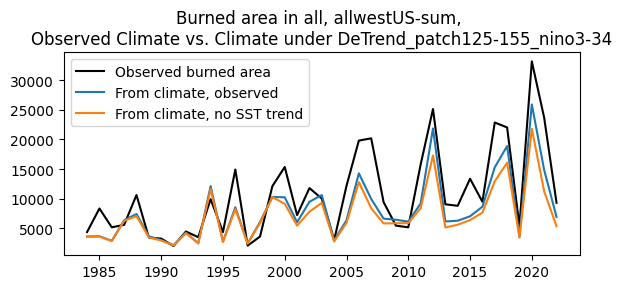

In [24]:
# all data
wumicol = np.array(wumi.iloc[:,iecoreg])
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
ax.plot(yearxaxis, dfclimpredBAall_wUS, label='From climate, observed')
ax.plot(yearxaxis, dfsstpredBAall_wUS, label='From climate, no SST trend')
ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

### forest

In [25]:
landname = 'for'
x = len(dfsstpredBAall[0,:]) # the number of columns
# sum across all columns except the first all WUS one
dfsstpredBAfor_wUS = (10**dfsstpredBAfor[:,1:x]).sum(axis=1)
dfclimpredBAfor_wUS = (10**dfclimpredBAfor[:,1:x]).sum(axis=1)

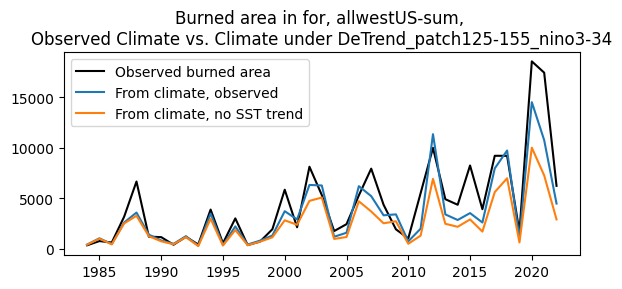

In [26]:
# all data
wumicol = np.array(wumifor.iloc[:,iecoreg])
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
ax.plot(yearxaxis, dfclimpredBAfor_wUS, label='From climate, observed')
ax.plot(yearxaxis, dfsstpredBAfor_wUS, label='From climate, no SST trend')
ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

### nonforest

In [27]:
landname = 'non'
x = len(dfsstpredBAall[0,:]) # the number of columns
# sum across all columns except the first all WUS one
dfsstpredBAnon_wUS = (10**dfsstpredBAnon[:,1:x]).sum(axis=1)
dfclimpredBAnon_wUS = (10**dfclimpredBAnon[:,1:x]).sum(axis=1)

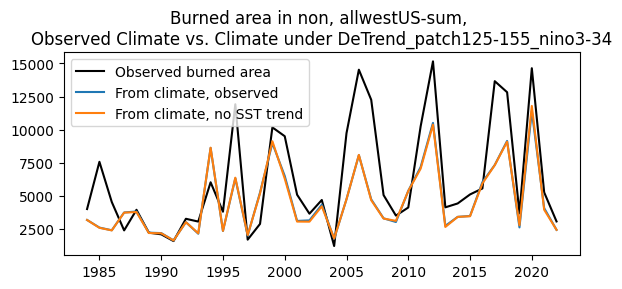

In [28]:
# all data
wumicol = np.array(wuminon.iloc[:,iecoreg])
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
ax.plot(yearxaxis, dfclimpredBAnon_wUS, label='From climate, observed')
ax.plot(yearxaxis, dfsstpredBAnon_wUS, label='From climate, no SST trend')
ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

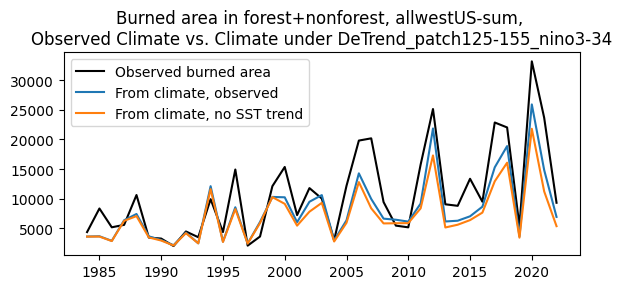

In [29]:
# forest+nonforest
wumicol = np.array(wumi.iloc[:,iecoreg])
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
sum_burnareapredobs =  dfclimpredBAfor_wUS + dfclimpredBAnon_wUS
sum_burnareapred = dfsstpredBAfor_wUS + dfsstpredBAnon_wUS
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
ax.plot(yearxaxis, sum_burnareapredobs, label='From climate, observed')
ax.plot(yearxaxis, sum_burnareapred, label='From climate, no SST trend')
ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in forest+nonforest, '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+'for+non'+'_'+ecoregname+'_BurnAreaPred')

# Ensemble Error

Replaces the current `wumifor`, `wuminon`, `dfclimpredBAfor`, and `dfclimpredBAnon`

September 4, 2024

* BA_mod = modeled burned area
* BA_obs = observed burned area

Method is as follows:
1. Calculate the time series of errors `BA_error_log10 = log10(BA_obs) - log10(BA_mod)`
3. make an ensemble of 500 time series of `log10(BA_mod_plus_error)`.
    * for each step in the time series of `BA_mod`, the error is randomly selected and added to the step in the time series by sampling from the time series of `BA_error_log10` with replacement, not including sampling from the index year being selected for.
    * Result is one 39x500 matrix (years x ensembles) of randomly-selected years is created, and used to pick for all of the ecoprovinces and timeseries at once.
4. Un-log all 500 time series of log10(BA_mod_plus_error) to get the 500-member ensemble in original km^2 units.
5. Convert negative values to 0 km^2
6. Take the average of all 500 time series.

In [30]:
# import OBSERVED burned area wumi
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')

# import DETRENDED burned area wumi
filename = predict_string + 'BurnArea_wumiDT'
filenameend = '_'+str(firstyear)+'-'+str(finalyear)+'.txt'
wumiDT = pd.read_csv(filename+'_all_'+climfilename+filenameend).set_index('Unnamed: 0')
wumiforDT = pd.read_csv(filename+'_for_'+climfilename+filenameend).set_index('Unnamed: 0')
wuminonDT = pd.read_csv(filename+'_non_'+climfilename+filenameend).set_index('Unnamed: 0')

# PREDICTED BURNED AREA from observed SST and observed climate 
# (Model_ENSOfull12-2022 must be updated)

#filename = predict_string + 'BurnArea_'
filename = predict_string + 'BurnArea_'

# predicted burned area from observed climate
#BAclimpredall = pd.read_csv(filename+'climpred_all_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor = pd.read_csv(filename+'climpred_for_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon = pd.read_csv(filename+'climpred_non_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

# predicted burned area removing SST gradient trend
# (observed climate - climate without effect of SST trend)
#BAclimpredall_DT = pd.read_csv(filename+'sstpred_all_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor_DT = pd.read_csv(filename+'sstpred_for_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon_DT = pd.read_csv(filename+'sstpred_non_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

In [31]:
# log all wumi values
# BAclimpred is already log
BA_obsfor = np.ma.masked_invalid(np.log10(wumifor)).filled(0)
BA_obsnon = np.ma.masked_invalid(np.log10(wuminon)).filled(0)
BA_obsfor = pd.DataFrame(BA_obsfor, index=yearxaxis, columns=dfnames)
BA_obsnon = pd.DataFrame(BA_obsnon, index=yearxaxis, columns=dfnames)

# get log difference BA_obs - BA_model
BA_errorfor_log10 = BA_obsfor - BAclimpredfor
BA_errornon_log10 = BA_obsnon - BAclimprednon

/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/pandas/core/internals/blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


In [32]:
# EXPORT CLIMATE-PREDICTED (SST TRENDED) AND
# SST-PREDICTED (SST-DETRENDED) MODELED BA

# iterate through each ecoprovince
nensemble = 500 # number of ensemble members

# storage for final
BA_mod_plus_errorfor = np.empty((0,len(yearxaxis)))
BA_mod_plus_errornon = np.empty((0,len(yearxaxis)))
BA_modDT_plus_errorfor = np.empty((0,len(yearxaxis)))
BA_modDT_plus_errornon = np.empty((0,len(yearxaxis)))

# first make matrix of random years (n_years x n_ensemble members)
# RULE: 
istop = 0
iyears = np.arange(0,len(yearxaxis))
errormatrix = np.empty((0,len(yearxaxis)))
while istop < (nensemble):
    tmprandom = np.array([np.random.choice(np.delete(iyears, i)) for i in range(len(iyears))])
    # randomly select errors and construct a timeseries
    tmprandom = tmprandom.reshape(1, -1)
    errormatrix = np.concatenate([errormatrix, 
                                  tmprandom], axis=0)
    istop+=1

# for one ecoregion
# pick ecoregion name, select column
for thisregion in dfnames:   
    # select the modeled BA
    tmpBAmodfor = BAclimpredfor.loc[:,thisregion] # trended SST
    tmpBAmodnon = BAclimprednon.loc[:,thisregion]
    tmpBAmodDTfor = BAclimpredfor_DT.loc[:,thisregion] # detrended SST
    tmpBAmodDTnon = BAclimprednon_DT.loc[:,thisregion]

    # select errors according to errormatrix
    tmperrorfor = BA_errorfor_log10.loc[:,thisregion] # error BA_obs-BA_mod(trended)
    tmperrornon = BA_errornon_log10.loc[:,thisregion]
    tmpBA_randomerrorfor = np.empty((0,len(yearxaxis)))
    tmpBA_randomerrornon = np.empty((0,len(yearxaxis)))
    # iterate through errormatrix
    for j in np.arange(0,nensemble):
        tmpcolerrorfor = tmperrorfor.iloc[errormatrix[j]].values.reshape(1, -1)
        tmpcolerrornon = tmperrornon.iloc[errormatrix[j]].values.reshape(1, -1)
        tmpBA_randomerrorfor = np.concatenate([tmpBA_randomerrorfor, 
                                               tmpcolerrorfor], axis=0)
        tmpBA_randomerrornon = np.concatenate([tmpBA_randomerrornon, 
                                               tmpcolerrornon], axis=0)

    # add BA_model to the errors, then unlog
    tmpBA_mod_plus_errorfor = 10**(tmpBAmodfor.values[:, np.newaxis] + tmpBA_randomerrorfor.T)
    tmpBA_mod_plus_errornon = 10**(tmpBAmodnon.values[:, np.newaxis] + tmpBA_randomerrornon.T)
    tmpBA_modDT_plus_errorfor = 10**(tmpBAmodDTfor.values[:, np.newaxis] + tmpBA_randomerrorfor.T)
    tmpBA_modDT_plus_errornon = 10**(tmpBAmodDTnon.values[:, np.newaxis] + tmpBA_randomerrornon.T)
    
    # create pd dataframe
    tmpBA_mod_plus_errorfor = pd.DataFrame(tmpBA_mod_plus_errorfor, index=yearxaxis)
    tmpBA_mod_plus_errornon = pd.DataFrame(tmpBA_mod_plus_errornon, index=yearxaxis)
    tmpBA_modDT_plus_errorfor = pd.DataFrame(tmpBA_modDT_plus_errorfor, index=yearxaxis)
    tmpBA_modDT_plus_errornon = pd.DataFrame(tmpBA_modDT_plus_errornon, index=yearxaxis)

    # RULE: set negative values to zero
    tmpBA_mod_plus_errorfor[tmpBA_mod_plus_errorfor<0] = 0
    tmpBA_mod_plus_errornon[tmpBA_mod_plus_errornon<0] = 0
    tmpBA_modDT_plus_errorfor[tmpBA_modDT_plus_errorfor<0] = 0
    tmpBA_modDT_plus_errornon[tmpBA_modDT_plus_errornon<0] = 0
    
    # take mean mod+error of all n columns
    tmpBA_mod_plus_errorfor1 = tmpBA_mod_plus_errorfor.mean(axis=1).values.reshape(1, -1)
    tmpBA_mod_plus_errornon1 = tmpBA_mod_plus_errornon.mean(axis=1).values.reshape(1, -1)
    tmpBA_modDT_plus_errorfor1 = tmpBA_modDT_plus_errorfor.mean(axis=1).values.reshape(1, -1)
    tmpBA_modDT_plus_errornon1 = tmpBA_modDT_plus_errornon.mean(axis=1).values.reshape(1, -1)
    
    # append to DF
    BA_mod_plus_errorfor = np.concatenate([BA_mod_plus_errorfor, 
                                           tmpBA_mod_plus_errorfor1], axis=0)
    BA_mod_plus_errornon = np.concatenate([BA_mod_plus_errornon, 
                                           tmpBA_mod_plus_errornon1], axis=0)
    BA_modDT_plus_errorfor = np.concatenate([BA_modDT_plus_errorfor, 
                                           tmpBA_modDT_plus_errorfor1], axis=0)
    BA_modDT_plus_errornon = np.concatenate([BA_modDT_plus_errornon, 
                                           tmpBA_modDT_plus_errornon1], axis=0)

# convert final result to DF
BA_mod_plus_errorfor = pd.DataFrame(BA_mod_plus_errorfor.T, 
                                    index=yearxaxis, columns=dfnames)
BA_mod_plus_errornon = pd.DataFrame(BA_mod_plus_errornon.T,
                                    index=yearxaxis, columns=dfnames)
BA_modDT_plus_errorfor = pd.DataFrame(BA_modDT_plus_errorfor.T, 
                                    index=yearxaxis, columns=dfnames)
BA_modDT_plus_errornon = pd.DataFrame(BA_modDT_plus_errornon.T,
                                    index=yearxaxis, columns=dfnames)
# replace all western US column with sum
BA_mod_plus_errorfor['allwestUS'] = BA_mod_plus_errorfor.iloc[:,1:].sum(axis=1)
BA_mod_plus_errornon['allwestUS'] = BA_mod_plus_errornon.iloc[:,1:].sum(axis=1)
BA_modDT_plus_errorfor['allwestUS'] = BA_modDT_plus_errorfor.iloc[:,1:].sum(axis=1)
BA_modDT_plus_errornon['allwestUS'] = BA_modDT_plus_errornon.iloc[:,1:].sum(axis=1)


# prep for export, reassign to variable names
dfclimpredBAall = np.log10(BA_mod_plus_errorfor+BA_mod_plus_errornon).values
dfclimpredBAfor = np.log10(BA_mod_plus_errorfor).values
dfclimpredBAnon = np.log10(BA_mod_plus_errornon).values

dfsstpredBAall = np.log10(BA_modDT_plus_errorfor+BA_modDT_plus_errornon).values
dfsstpredBAfor = np.log10(BA_modDT_plus_errorfor).values
dfsstpredBAnon = np.log10(BA_modDT_plus_errornon).values

In [33]:
# export overwrite
dictoutputs = [dfsstpredBAall, dfsstpredBAfor, dfsstpredBAnon,
               dfclimpredBAall, dfclimpredBAfor, dfclimpredBAnon]
dictoutputnames = ['sstpred_all', 'sstpred_for', 'sstpred_non',
                   'climpred_all','climpred_for','climpred_non']
# convert to pandas df and export
for i,thisdict in enumerate(dictoutputs):
    tmpoutput = pd.DataFrame(thisdict, columns=[dfnames], index=yearxaxis)
    if i<3: # export the SST-predicted
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    if (i>=3) & (i<6): # export the climate-predicted
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    print('Exported: '+filename)

Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_all_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_for_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_non_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_all_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_for_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_non_1984-2022.txt


In [34]:
# datetime object containing current date and time
from datetime import datetime
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Model last run =", dt_string)

Model last run = 18/11/2025 11:02:50
